# 🎯 3. Agent Loops and Core Architecture

In notebooks 01-02 we learned what agents are and how LLMs serve as their brain. Now we **build** our first agents.

We will cover:

1. **The minimal agent loop** — a while-loop with LLM + tools
2. **State management** — tracking agent state with TypedDict
3. **Stopping conditions** — how and when the agent finishes
4. **LangGraph StateGraph** — the professional way to build agent graphs
5. **Conditional edges** — dynamic routing based on agent decisions
6. **From scratch to framework** — understanding what LangGraph abstracts

### Agent

- autonomous unit
- with a LLM
- role
- goal
- backstore
- memory
- tools

In [6]:
import os
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import display, Markdown

# Φορτώνουμε τα API keys από το .env (βρίσκεται στο root του project)
_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=False)

# Αν δεν βρεθεί το key (πχ σε Colab), ζητάμε manually
# if not os.environ.get("OPENAI_API_KEY"):
#     import getpass
#     os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

LLM_MODEL   = "gpt-4o-mini"

print(f'Model: {LLM_MODEL}')
print(f'API key configured: {bool(os.getenv("OPENAI_API_KEY"))}')

Model: gpt-4o-mini
API key configured: True


## 3.1 Building an Agent Loop from Scratch

Before using any framework, let's build the agent pattern from first principles. This is the pattern that **every** agent framework implements under the hood.

The core idea:

<img src="images/agent-loop-1.png" width="50%" style="border-radius:10px;margin:12px 0;"/>

In [7]:
from openai import OpenAI
import json

client = OpenAI()

# ── Define Tools ──
def get_weather(city: str) -> str:
    """Simulated weather API."""
    weather_data = {
        'london': 'Cloudy, 12°C, 60% humidity',
        'tokyo': 'Sunny, 24°C, 45% humidity',
        'new york': 'Rainy, 8°C, 85% humidity',
        'paris': 'Partly cloudy, 16°C, 55% humidity',
    }
    return weather_data.get(city.lower(), f'No data for {city}')

def calculate(expression: str) -> str:
    """Safe math evaluator."""
    allowed = set('0123456789+-*/.() ')
    if all(c in allowed for c in expression):
        return str(eval(expression))
    return 'Error: invalid expression'

# Tool registry — maps names to functions
TOOL_REGISTRY = {
    'get_weather': get_weather,
    'calculate': calculate,
}

# Tool schemas for OpenAI
TOOL_SCHEMAS = [
    {
        'type': 'function',
        'function': {
            'name': 'get_weather',
            'description': 'Get current weather for a city',
            'parameters': {
                'type': 'object',
                'properties': {'city': {'type': 'string', 'description': 'City name'}},
                'required': ['city']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'calculate',
            'description': 'Evaluate a math expression',
            'parameters': {
                'type': 'object',
                'properties': {'expression': {'type': 'string', 'description': 'Math expression'}},
                'required': ['expression']
            }
        }
    }
]

print(f'Registered {len(TOOL_REGISTRY)} tools: {list(TOOL_REGISTRY.keys())}')

Registered 2 tools: ['get_weather', 'calculate']


In [3]:
# Όλο το χειροκίνητο run_agent() loop (με thinking, acting, observing,
# tool dispatch και stopping condition) είναι ακριβώς αυτό που
# υλοποιεί εσωτερικά η create_agent. Δείτε εδώ το ίδιο
# αποτέλεσμα σε 3 γραμμές:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain.agents import create_agent

@tool
def get_weather_tool(city: str) -> str:
    """Get current weather for a city."""
    return get_weather(city)

@tool
def calculate_tool(expression: str) -> str:
    """Safely evaluate a math expression."""
    return calculate(expression)

agent_react = create_agent(
    model=ChatOpenAI(model=LLM_MODEL, temperature=0),
    tools=[get_weather_tool, calculate_tool],
    system_prompt='You are a helpful assistant with access to tools. Use tools when needed.',
)

out = agent_react.invoke({'messages': [HumanMessage(content='What is the weather in london?')]})
print(out['messages'][-1].content)


c:\Users\user\Desktop\ai-agents-for-devs\venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


The weather in London is currently cloudy, with a temperature of 12°C and 60% humidity.


In [8]:
# Test the factory agent with a multi-step query
out = agent_react.invoke({
    'messages': [HumanMessage(content='What is the weather in Tokyo, and what is 23 * 47?')]
})
for m in out['messages']:
    role = m.__class__.__name__
    if hasattr(m, 'tool_calls') and m.tool_calls:
        for tc in m.tool_calls:
            print(f'  → {tc["name"]}({tc["args"]})')
    elif getattr(m, 'content', None):
        print(f'{role}: {m.content}')


HumanMessage: What is the weather in Tokyo, and what is 23 * 47?
  → get_weather_tool({'city': 'Tokyo'})
  → calculate_tool({'expression': '23 * 47'})
ToolMessage: Sunny, 24°C, 45% humidity
ToolMessage: 1081
AIMessage: The weather in Tokyo is sunny with a temperature of 24°C and 45% humidity. Additionally, the result of \( 23 \times 47 \) is 1081.


## 3.2 State Management with TypedDict

Our from-scratch agent used a simple `messages` list. In real applications, agents need richer state:

- **Messages**: the conversation history
- **Current step**: where we are in the workflow
- **Intermediate results**: tool outputs, computed values
- **Metadata**: timestamps, token counts, error flags

Python's `TypedDict` gives us type-safe state management:

In [5]:
from typing import TypedDict, Annotated
import operator

class AgentState(TypedDict):
    """State that the agent maintains across steps."""
    messages: Annotated[list, operator.add] # Append-only message list
    current_step: str                       # Which node is executing
    tools_call_made: int                    # How many tools we've called
    is_complete: bool                       # Whether the agent is done

# Initial state
initial_state: AgentState = {
    "messages": [{"role": "user", "content":"Hello"}],
    "current_step": "start",
    "tools_call_made": 0,
    "is_complete": False,
}

print(f"State keys: {list(initial_state.keys())}")
print(f"Messages: {len(initial_state["messages"])}")
print(f"Step: {initial_state['current_step']}")

State keys: ['messages', 'current_step', 'tools_call_made', 'is_complete']
Messages: 1
Step: start


## 3.3 Introduction to LangGraph

**LangGraph** is the production framework for building agent workflows as **directed graphs**.

Core concepts:
- **StateGraph**: The graph definition — nodes and edges
- **Nodes**: Functions that process state (the steps)
- **Edges**: Connections between nodes (the flow)
- **Conditional Edges**: Dynamic routing based on state
- **START / END**: Special nodes marking entry and exit


<img src="images/intro-to-langgraph.png" width="70%" style="border-radius:10px;margin:12px 0;"/>

In [9]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

class ConverstationState(TypedDict):
    messages: Annotated[list, operator.add]
    sentiment: str
    response_count: int

llm = ChatOpenAI(model=LLM_MODEL, temperature=0)

# Define nodes
def analyze_sentiment(state: ConverstationState) -> dict:
    """Node 1: Analyse the sentiment of the user's message"""
    last_msg = state['messages'][-1]
    content = last_msg.content if hasattr(last_msg, 'content') else str(last_msg)

    response = llm.invoke([
        SystemMessage(content="Clasify the sentiment as: positive, negative or neutral. Reply with just the word"),
        HumanMessage(content=content)
    ])

    sentiment = response.content.strip().lower()
    print(f" [analyze_sentiment] Detected: {sentiment}")
    return {'sentiment': sentiment}

def generate_response(state: ConverstationState) -> dict:
    """Node 2: Generate a response appropriate to the sentiment"""
    sentiment = state['sentiment']
    last_msg = state['messages'][-1]
    content = last_msg.content if hasattr(last_msg, 'content') else str(last_msg)

    prompts = {
        "positive": "Respond enthusiastically and build on their energy.",
        "negative": "Respond empathetically and offer support.",
        "neutral": "Respond helpfully and informatively."
    }

    response = llm.invoke([
        SystemMessage(content=prompts.get(sentiment, prompts["neutral"])),
        HumanMessage(content=content)
    ])

    print(f" [generate_response] Generated reply")
    return {
        "messages": [AIMessage(content=response.content)],
        'response_count': 1
    }

# Build Graph
graph = StateGraph(ConverstationState)

# Add nodes
graph.add_node('analyze_sentiment', analyze_sentiment)
graph.add_node('generate_response', generate_response)

# Add edges
graph.add_edge(START, 'analyze_sentiment')
graph.add_edge('analyze_sentiment', 'generate_response')
graph.add_edge('generate_response', END)

# Compile
app = graph.compile()
print("Graph is ready!")

Graph is ready!


<img src="images/start-analyse-gen-end.png" width="70%" style="border-radius:10px;margin:12px 0;"/>

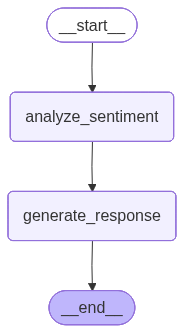

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
test_messages = [
    "I just got promoted at work! So exited!",
    "My compter crashed and i lost all my work...",
    "What time is the meeting tomorrow?"
]

for msg in test_messages:
    print(f'\n{"-"*60}')
    print(f"User: {msg}")

    result = app.invoke(
        {
            "messages": [HumanMessage(content=msg)],
            "sentiment": '',
            "response_count":0
        }
    )

    print(f"Sentiment: {result['sentiment']}")
    print(f"Response: {result['messages'][-1].content}")


------------------------------------------------------------
User: I just got promoted at work! So exited!
 [analyze_sentiment] Detected: positive
 [generate_response] Generated reply
Sentiment: positive
Response: That’s amazing! Congratulations! 🎉 Your hard work and dedication have truly paid off! How are you planning to celebrate this incredible achievement? This is such a fantastic milestone in your career!

------------------------------------------------------------
User: My compter crashed and i lost all my work...
 [analyze_sentiment] Detected: negative
 [generate_response] Generated reply
Sentiment: negative
Response: I'm really sorry to hear that your computer crashed and you lost all your work. That must be incredibly frustrating and disheartening. It’s tough to put in so much effort only to have it disappear like that. If you need someone to talk to about it or if you’re looking for ways to recover your work or prevent this from happening in the future, I’m here to help. Yo

## 3.4 Conditional Edges — Dynamic Routing

Real agents don't follow a fixed path. They make **decisions** at each step. LangGraph supports this with **conditional edges** — functions that return the next node based on state.

<img src="images/conditional-edges-dynamic-routing.png" width="50%" style="border-radius:10px;margin:12px 0;"/>

In [20]:
from typing import Literal

class RouterState(TypedDict):
    messages: Annotated[list, operator.add]
    query_type: str
    result: str

def classify_query(state: RouterState) -> dict:
    last_msg = state['messages'][-1]
    content = last_msg.content if hasattr(last_msg, 'content') else str(last_msg)

    response = llm.invoke([
        SystemMessage(content=(
            "Classify the query type. Reply with exactly one word: "
            "math, weather, or general"
        )),
        HumanMessage(content=content)
    ])

    query_type = response.content.strip().lower()
    print(f" [classify] Type: {query_type}")
    return {'query_type': query_type}

def handle_math(state: RouterState) -> dict:
    print('  [handle_math] Processing math query...')
    last_msg = state['messages'][-1]
    content = last_msg.content if hasattr(last_msg, 'content') else str(last_msg)
    resp = llm.invoke([SystemMessage(content='Solve the math problem step by step.'), HumanMessage(content=content)])
    return {'result': resp.content, 'messages': [AIMessage(content=resp.content)]}

def handle_weather(state: RouterState) -> dict:
    print('  [handle_weather] Processing weather query...')
    return {'result': 'Weather data: Sunny, 22°C (simulated)', 'messages': [AIMessage(content='Weather: Sunny, 22°C')]}

def handle_general(state: RouterState) -> dict:
    print('  [handle_general] Processing general query...')
    last_msg = state['messages'][-1]
    content = last_msg.content if hasattr(last_msg, 'content') else str(last_msg)
    resp = llm.invoke([SystemMessage(content='Answer helpfully and concisely.'), HumanMessage(content=content)])
    return {'result': resp.content, 'messages': [AIMessage(content=resp.content)]}

def route_query(state: RouterState) -> str:
    """Returns the name of the next node based on the query_type"""
    qt = state.get('query_type', 'general')
    if 'math' in qt:
        return 'handle_math'
    elif 'weather' in qt:
        return 'handle_weather'
    else:
        return "handle_general"

# Build Graph
router_graph = StateGraph(RouterState)

# Add Nodes
router_graph.add_node('classify', classify_query)
router_graph.add_node('handle_math', handle_math)
router_graph.add_node('handle_weather', handle_weather)
router_graph.add_node('handle_general', handle_general)

# Add edges
router_graph.add_edge(START, 'classify')
router_graph.add_conditional_edges('classify', route_query)
router_graph.add_edge('handle_math', END)
router_graph.add_edge('handle_weather', END)
router_graph.add_edge('handle_general', END)

router_app = router_graph.compile()
print("Router Graph is ready!")

Router Graph is ready!


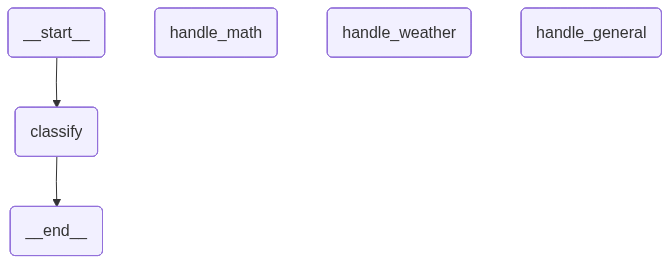

In [15]:
display(Image(router_app.get_graph().draw_mermaid_png()))

In [18]:
from IPython.display import display, Markdown

# Test the router with different query types
queries = [
    'What is 157 * 34 + 22? (No LaTeX.)',
    'What is the weather like in London? (No LaTeX.)',
    'Explain what machine learning is. (No LaTeX.)'
]

for q in queries:
    print(f'\n{"─"*50}')
    print(f'Query: {q}')
    result = router_app.invoke({
        'messages': [HumanMessage(content=q)],
        'query_type': '',
        'result': ''
    })

    # print(f'Result: {result["result"]}')
    display(Markdown("### Results"))
    display(Markdown(result["result"]))


──────────────────────────────────────────────────
Query: What is 157 * 34 + 22? (No LaTeX.)
 [classify] Type: math
  [handle_math] Processing math query...


### Results

To solve the expression 157 * 34 + 22, we will follow these steps:

1. First, calculate 157 * 34.
2. Then, add 22 to the result of that multiplication.

Step 1: Calculate 157 * 34.

157 * 34 = 5338

Step 2: Now, add 22 to the result.

5338 + 22 = 5360

So, the final answer is 5360.


──────────────────────────────────────────────────
Query: What is the weather like in London? (No LaTeX.)
 [classify] Type: weather
  [handle_weather] Processing weather query...


### Results

Weather data: Sunny, 22°C (simulated)


──────────────────────────────────────────────────
Query: Explain what machine learning is. (No LaTeX.)
 [classify] Type: general
  [handle_general] Processing general query...


### Results

Machine learning is a subset of artificial intelligence that focuses on the development of algorithms and statistical models that enable computers to learn from and make predictions or decisions based on data. Instead of being explicitly programmed for specific tasks, machine learning systems improve their performance as they are exposed to more data over time. This process involves training a model on a dataset, allowing it to identify patterns and relationships, which can then be applied to new, unseen data to generate insights or automate tasks. Machine learning is used in various applications, including image recognition, natural language processing, recommendation systems, and more.

## 💡 Exercise 3: Build a Support Ticket Router

**Task**: Build a LangGraph that:
1. Takes a customer message
2. Classifies it (billing, technical, feedback)
3. Routes to the appropriate handler
4. Each handler generates a tailored response

Hints:
- Define a `TicketState` with `messages`, `category`, and `response`
- Create a `classify` node and three handler nodes
- Use `add_conditional_edges` for routing

In [12]:
# Exercise 3: Build your Support Ticket Router
# YOUR CODE HERE

# class TicketState(TypedDict):
#     ...

# def classify_ticket(state):
#     ...

# ticket_graph = StateGraph(TicketState)
# ...


## 📝 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Agent Loop** | `while not done: think → act → observe` — the universal agent pattern |
| **State** | TypedDict with `Annotated[list, operator.add]` for message accumulation |
| **LangGraph** | StateGraph + nodes + edges = production-grade agent workflows |
| **Conditional Edges** | `add_conditional_edges(node, router_fn)` for dynamic routing |
| **From Scratch → Framework** | Our raw loop and LangGraph implement the same pattern |

### What's Next

In **Notebook 04: Tools and Function Calling**, we dive deep into the **tools** that give agents their power — function schemas, tool registries, LangChain's `@tool` decorator, and LangGraph's ToolNode.